In [34]:
# ACCESO A DATOS

In [36]:
import pandas as pd

url = "https://storage.googleapis.com/jvelare-public/bq-results-20260211-093843-1770799837095"

df = pd.read_csv(url)



#print(df.head())  # vemos el nombre de las columnas y los primeros registros

for col in df.columns:
    print(col)

CODE
Sales_Date
Id_Producto
Customer_ID
PVP
MOTIVO_VENTA
FORMA_PAGO
EXTENSION_GARANTIA
SEGURO_BATERIA_LARGO_PLAZO
MANTENIMIENTO_GRATUITO
FIN_GARANTIA
BASE_DATE
EN_GARANTIA
COSTE_VENTA_NO_IMPUESTOS
GENERO
CODIGO_POSTAL
Edad
RENTA_MEDIA_ESTIMADA
ENCUESTA_CLIENTE_ZONA_TALLER
STATUS_SOCIAL
Modelo
TIPO_CARROCERIA
Fuel
TRANSMISION_ID
Equipamiento
Kw
Revisiones
Km_medio_por_revision
km_ultima_revision
QUEJA
Lead_compra
Fue_Lead
TIENDA_DESC
PROV_DESC
ZONA
Origen
Margen_eur_bruto
Margen_eur
DAYS_LAST_SERVICE
Churn_400


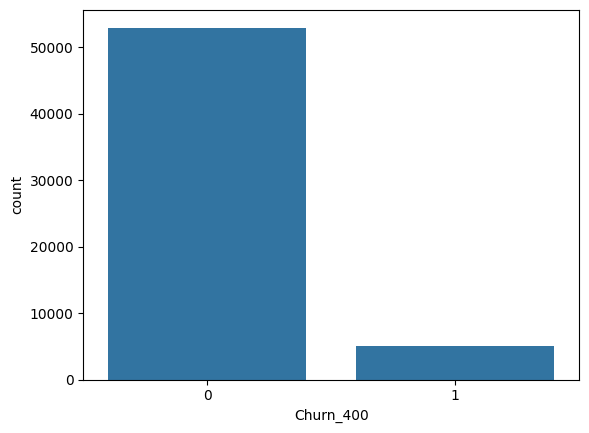

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convertir Churn_400 de Y/N a 1/0
df["Churn_400"] = (
    df["Churn_400"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map({"Y": 1, "N": 0}))

sns.countplot(x=df["Churn_400"]) # distribución de la variable objetivo (Churn_400), es decir, cuántos clientes se van (1) y cuántos se quedan (0)
plt.show()


In [38]:
print(df["Churn_400"].value_counts(dropna=False))
print(df["Churn_400"].unique())


Churn_400
0    52956
1     5093
Name: count, dtype: int64
[0 1]


In [39]:

print("Número de filas y columnas:")
print(df.shape) # vemos el tamaño del DataFrame 

Número de filas y columnas:
(58049, 40)


In [40]:
df.info() # vemos el tipo de datos de cada columna 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58049 entries, 0 to 58048
Data columns (total 40 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CODE                          58049 non-null  object 
 1   Sales_Date                    58049 non-null  object 
 2   Id_Producto                   58049 non-null  object 
 3   Customer_ID                   58049 non-null  int64  
 4   PVP                           58049 non-null  int64  
 5   MOTIVO_VENTA                  58049 non-null  object 
 6   FORMA_PAGO                    58049 non-null  object 
 7   EXTENSION_GARANTIA            58049 non-null  object 
 8   SEGURO_BATERIA_LARGO_PLAZO    58049 non-null  object 
 9   MANTENIMIENTO_GRATUITO        58049 non-null  int64  
 10  FIN_GARANTIA                  58049 non-null  object 
 11  BASE_DATE                     58049 non-null  object 
 12  EN_GARANTIA                   58049 non-null  object 
 13  C

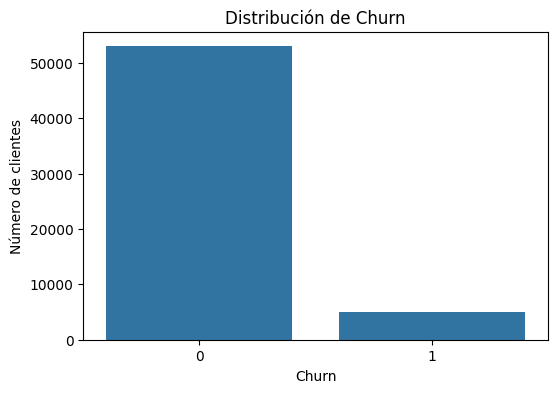

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(x=df["Churn_400"]) # con esto vemos si el dataset está balanceado o no, es decir, si hay más clientes que se van o que se quedan

plt.title("Distribución de Churn")
plt.xlabel("Churn")
plt.ylabel("Número de clientes")

plt.show()  

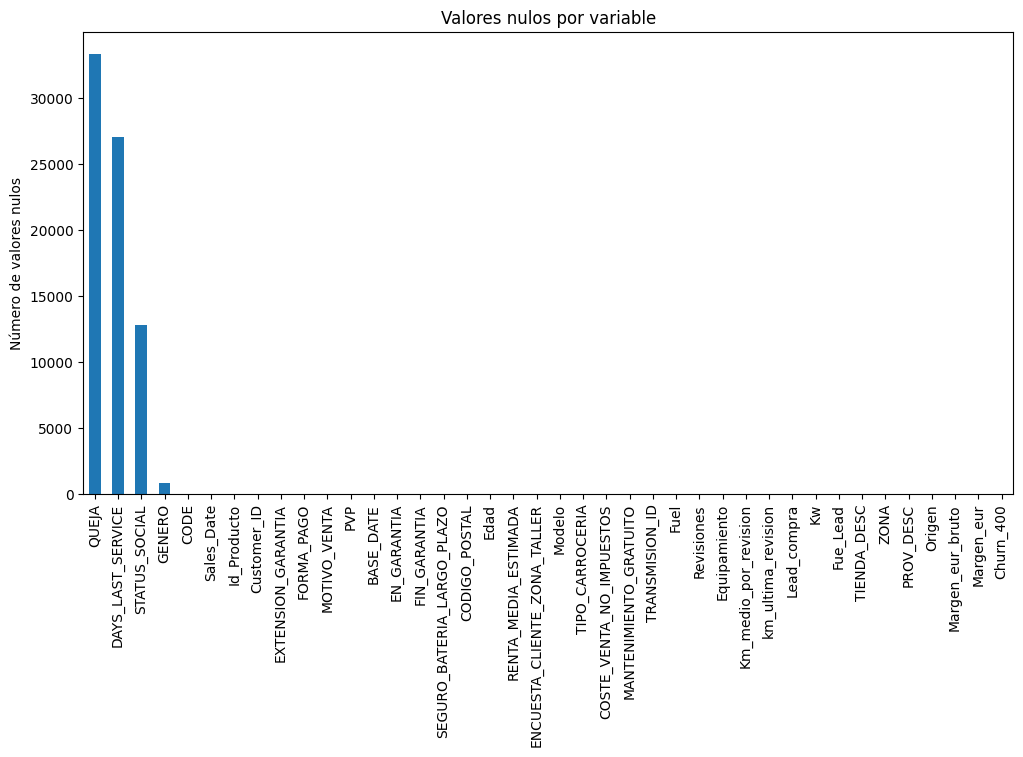

In [42]:
plt.figure(figsize=(12,6))

df.isnull().sum().sort_values(ascending=False).plot(kind="bar")
# vemos valores nulos por variable, ordenados de mayor a menor, con un gráfico de barras
plt.title("Valores nulos por variable")
plt.ylabel("Número de valores nulos")

plt.show()

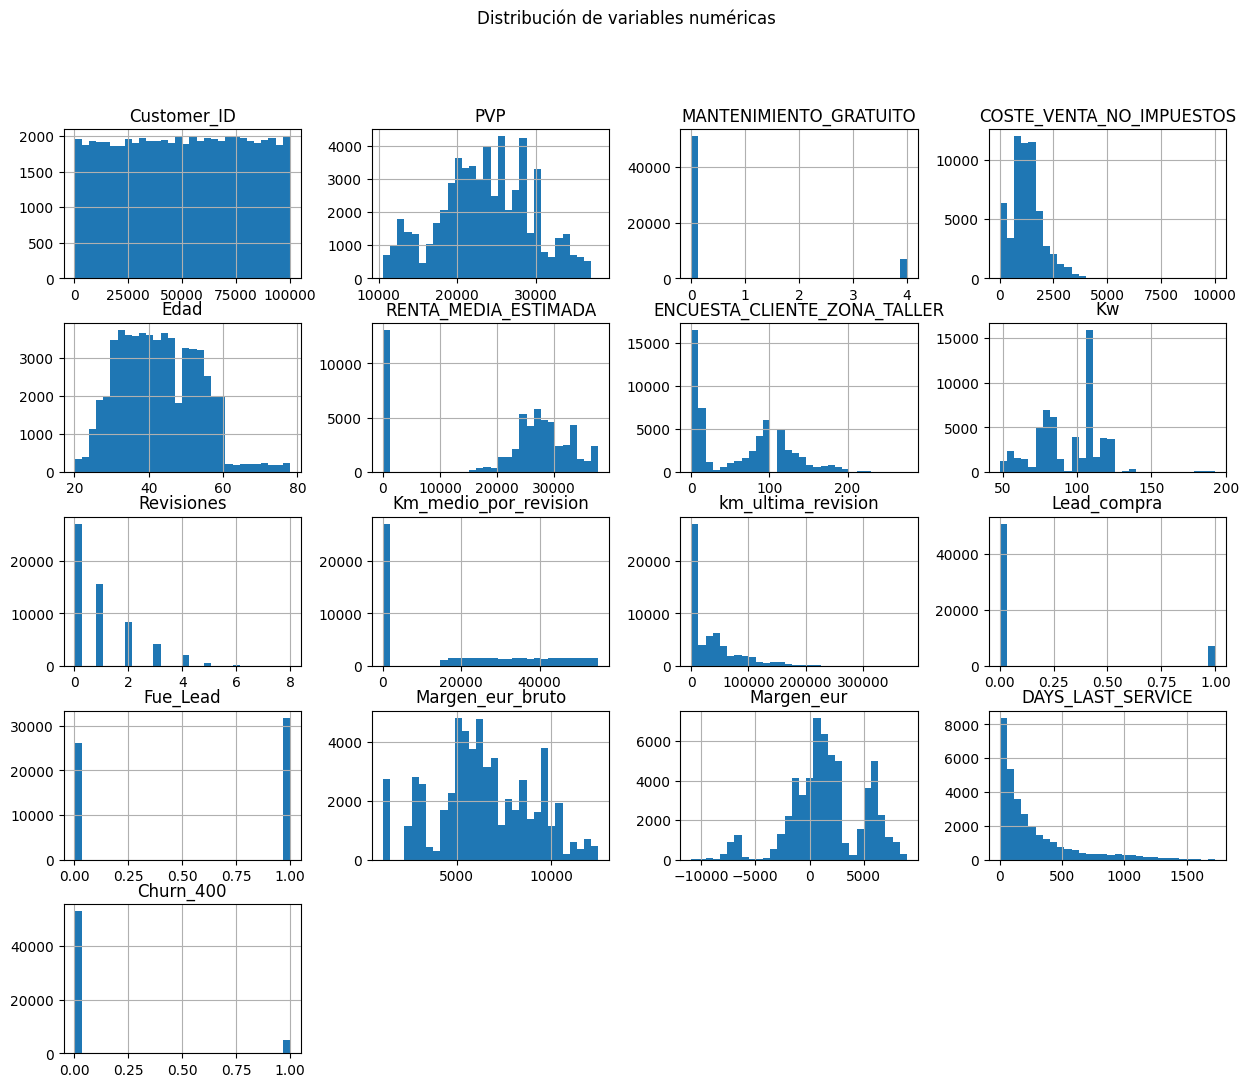

In [43]:
df.hist(figsize=(15,12), bins=30)
# con esto vemos la distribución de cada variable numérica, es decir, si son normales, sesgadas, etc. Esto nos puede ayudar a decidir qué tipo de modelo de machine learning usar, por ejemplo, si una variable es muy sesgada, podríamos usar un modelo que no asuma normalidad, como un árbol de decisión o un random forest.
plt.suptitle("Distribución de variables numéricas")

plt.show()

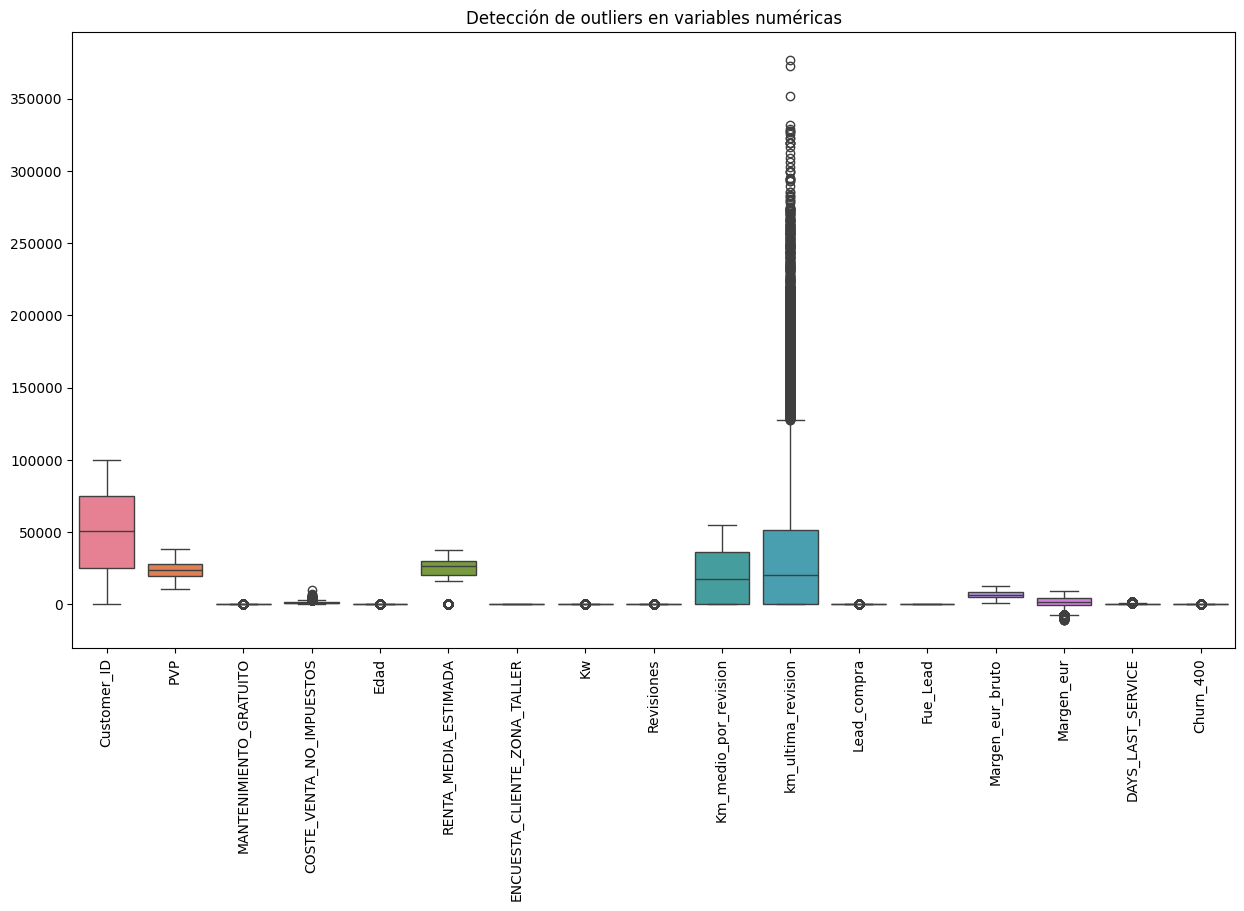

In [44]:
numeric_cols = df.select_dtypes(include=["number"]).columns

plt.figure(figsize=(15,8))

sns.boxplot(data=df[numeric_cols]) 
# vemos la presencia de outliers en cada variable numérica, lo que nos puede ayudar a decidir si es necesario hacer alguna transformación o eliminación de outliers antes de entrenar un modelo de machine learning. Por ejemplo, si una variable tiene muchos outliers, podríamos considerar usar una transformación logarítmica o eliminar los outliers para mejorar el rendimiento del modelo.

plt.xticks(rotation=90)

plt.title("Detección de outliers en variables numéricas")

plt.show()

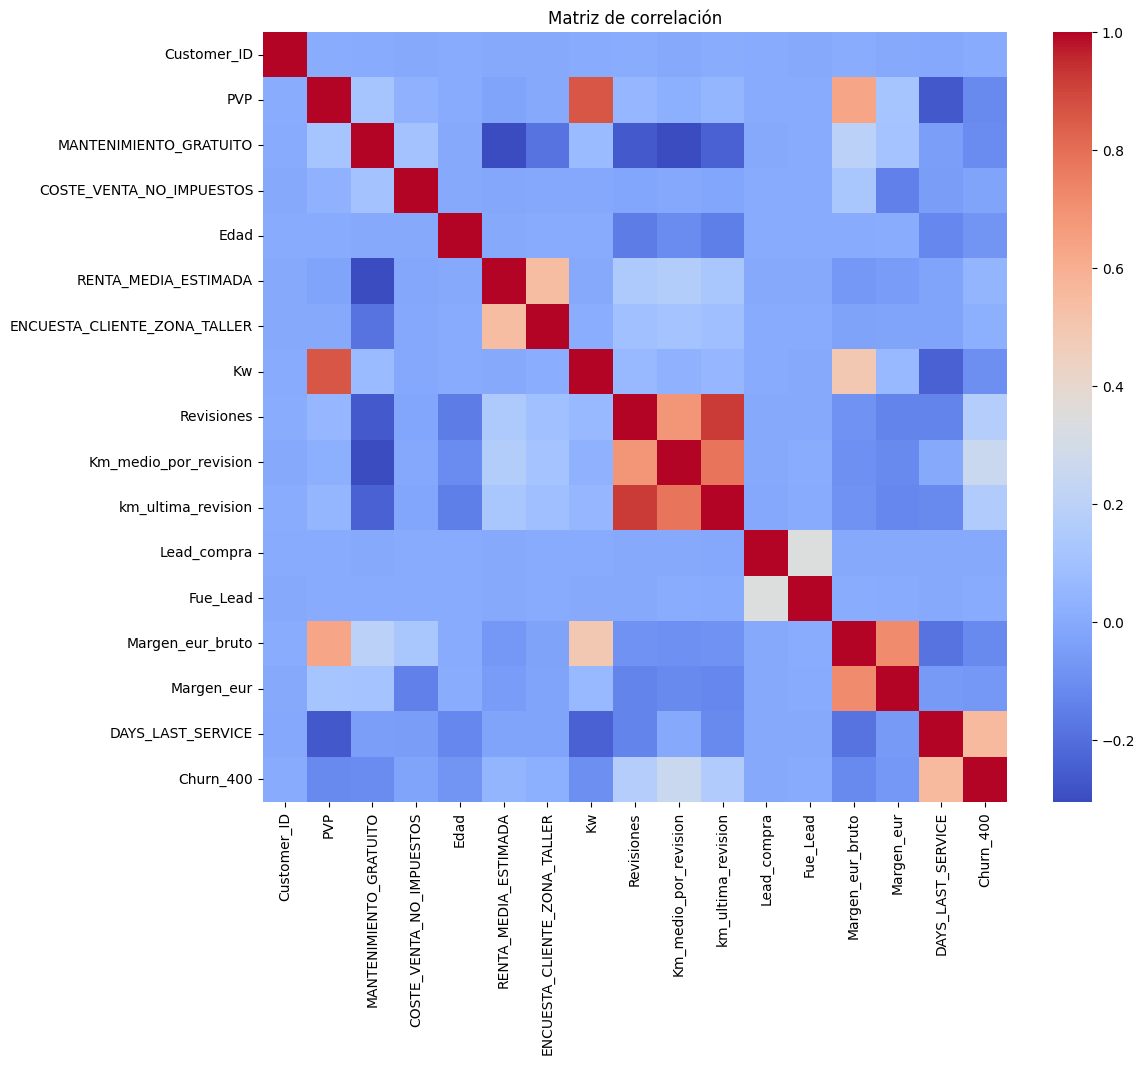

In [45]:
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)
# con esto vemos relaciones lineales entre variables numéricas, lo que nos puede ayudar a decidir qué variables usar como características para entrenar un modelo de machine learning. Por ejemplo, si una variable tiene una alta correlación con la variable objetivo (Churn_400), podríamos considerarla como una buena característica para el modelo. Además, si dos variables tienen una alta correlación entre sí, podríamos considerar eliminar una de ellas para evitar multicolinealidad en el modelo.
sns.heatmap(corr, cmap="coolwarm")

plt.title("Matriz de correlación")

plt.show()

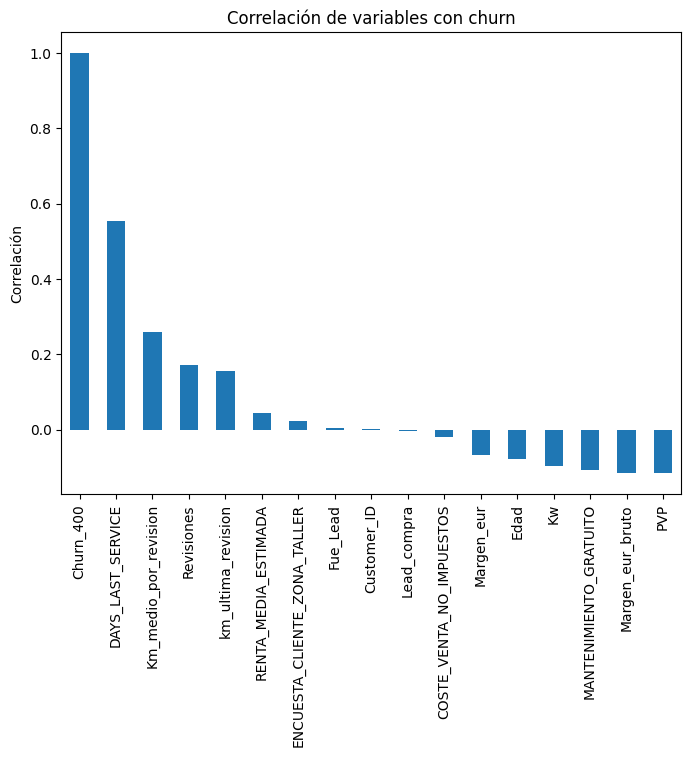

In [46]:
corr = df.corr(numeric_only=True)

churn_corr = corr["Churn_400"].sort_values(ascending=False)
# vemos las variables numéricas ordenadas por su correlación con la variable objetivo (Churn_400), lo que nos puede ayudar a decidir qué variables usar como características para entrenar un modelo de machine learning. Por ejemplo, si una variable tiene una alta correlación con Churn_400, podríamos considerarla como una buena característica para el modelo.
plt.figure(figsize=(8,6))

churn_corr.plot(kind="bar")

plt.title("Correlación de variables con churn")

plt.ylabel("Correlación")

plt.show()

In [52]:
# ver columnas de nuevos_clientes.csv enumando cada una de ellas

df2 = pd.read_csv("nuevos_clientes.csv") 
contador = 0
for col in df2.columns:
    contador += 1
    print(f"{contador}.{col}")
   


1.CODE
2.Sales_Date
3.Id_Producto
4.Customer_ID
5.PVP
6.MOTIVO_VENTA
7.FORMA_PAGO
8.EXTENSION_GARANTIA
9.SEGURO_BATERIA_LARGO_PLAZO
10.MANTENIMIENTO_GRATUITO
11.FIN_GARANTIA
12.BASE_DATE
13.EN_GARANTIA
14.COSTE_VENTA_NO_IMPUESTOS
15.GENERO
16.CODIGO_POSTAL
17.Edad
18.RENTA_MEDIA_ESTIMADA
19.ENCUESTA_CLIENTE_ZONA_TALLER
20.STATUS_SOCIAL
21.Modelo
22.TIPO_CARROCERIA
23.Fuel
24.TRANSMISION_ID
25.Equipamiento
26.Kw
27.Revisiones
28.Km_medio_por_revision
29.km_ultima_revision
30.QUEJA
31.Lead_compra
32.Lead_compra_1
33.TIENDA_DESC
34.PROV_DESC
35.ZONA
36.Origen
37.Margen_eur_bruto
38.Margen_eur


# Conclusiones del análisis exploratorio

Después de explorar el dataset podemos entender bastante bien qué tipo de información tenemos y qué nos puede decir sobre el comportamiento de los clientes.

El dataset contiene **58.049 clientes y 40 variables**, lo que nos da una base de datos suficientemente grande para analizar patrones de comportamiento y construir modelos predictivos. Las variables combinan información del cliente, del vehículo y del uso que el cliente hace del servicio de mantenimiento.

La variable que queremos predecir es **`Churn_400`**, que indica si un cliente ha abandonado o no la relación con el servicio. Tras convertirla a formato binario (1 = churn, 0 = no churn), observamos que el dataset está **claramente desbalanceado**: aproximadamente el **9% de los clientes abandona**, mientras que el **91% permanece activo**.

Desde el punto de vista de negocio esto es algo esperable. En la mayoría de empresas la gran mayoría de clientes continúa utilizando el servicio, y solo una pequeña parte abandona. Sin embargo, precisamente por eso **identificar con antelación a esos clientes que están en riesgo de churn puede tener un impacto importante en la rentabilidad**.

---

# Calidad y estructura de los datos

En general, el dataset presenta **una buena calidad de datos**. La mayoría de las variables están completas y no presentan problemas importantes de registros faltantes.

Sin embargo, algunas variables sí contienen un número relevante de valores nulos, entre ellas:

* `QUEJA`
* `DAYS_LAST_SERVICE`
* `STATUS_SOCIAL`

En algunos casos estos valores nulos pueden tener un significado implícito. Por ejemplo, si un cliente no tiene registrada una queja puede significar simplemente que **nunca ha tenido una incidencia con el servicio**, lo cual es información útil en sí misma.

Por otro lado, variables como `DAYS_LAST_SERVICE` podrían reflejar situaciones en las que el cliente **no ha vuelto al taller desde su última interacción**, algo que desde el punto de vista del negocio podría estar relacionado con un mayor riesgo de abandono.

Por lo tanto, antes de eliminar o imputar estos valores será necesario **analizar su significado dentro del contexto del negocio**.

---

# Comportamiento de las variables

El análisis de las distribuciones y los boxplots nos permite entender cómo se comportan diferentes características del cliente.

Variables como la edad o la renta estimada presentan distribuciones relativamente razonables, mientras que otras variables relacionadas con el uso del vehículo o el número de revisiones muestran distribuciones más asimétricas.

Esto es algo habitual en datos reales: no todos los clientes utilizan el servicio con la misma frecuencia, y algunos presentan comportamientos extremos que aparecen como outliers en los gráficos.

Desde una perspectiva de negocio, estos outliers no necesariamente representan errores en los datos, sino **clientes con patrones de uso muy diferentes**, lo cual puede ser precisamente lo que queramos detectar con nuestro modelo.

---

# Variables potencialmente relacionadas con el churn

Uno de los resultados más interesantes del análisis aparece al observar las correlaciones con la variable de churn.

Las variables que muestran mayor relación con el abandono del cliente están relacionadas principalmente con **la actividad del cliente en el taller**:

* días desde la última visita (`DAYS_LAST_SERVICE`)
* número de revisiones realizadas
* kilómetros asociados a revisiones
* kilómetros de la última revisión

Esto tiene una interpretación bastante clara desde el punto de vista del negocio.

Un cliente que:

* lleva mucho tiempo sin acudir al taller
* ha realizado pocas revisiones
* tiene poca actividad reciente

podría estar **perdiendo la relación con el servicio postventa**, lo que aumenta la probabilidad de que abandone definitivamente.

Esto sugiere que la relación entre el cliente y el servicio de mantenimiento es un factor clave para entender el churn.

---

# Qué significa esto para el negocio

El análisis exploratorio sugiere que **la fidelidad al servicio postventa parece ser uno de los factores más importantes para retener a los clientes**.

Si un cliente deja de interactuar con el taller durante largos periodos de tiempo, existe una mayor probabilidad de que abandone la relación con la empresa.

Desde el punto de vista del negocio, esto abre la puerta a estrategias como:

* campañas de recordatorio de revisiones
* promociones para clientes que llevan tiempo sin acudir al taller
* seguimiento específico de clientes con baja actividad reciente

Un modelo predictivo de churn podría ayudar a **identificar estos clientes antes de que abandonen**, permitiendo actuar de forma preventiva.

---

# Siguiente paso: preparar los datos para el modelo

Una vez que entendemos mejor el comportamiento de los datos, el siguiente paso consiste en preparar el dataset para construir un modelo predictivo.

En esta siguiente fase de **feature engineering** nos centraremos en:

* tratar adecuadamente los valores nulos
* transformar variables categóricas para que puedan ser utilizadas por los modelos
* seleccionar las variables más relevantes
* eliminar variables que no aporten valor predictivo

El objetivo final será construir un conjunto de variables que capture de la mejor manera posible los patrones de comportamiento del cliente, permitiendo al modelo identificar **qué clientes tienen mayor riesgo de churn** y facilitando así la toma de decisiones desde el punto de vista del negocio.
